In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# check that we've got everything correctly

In [2]:
for trial in range(1,29):
    print(f"trial: {trial}")
    for algo in ['EI','KG','EICF','TS']:
        res = torch.load(f"/home/pb482/bott/results/GT_230.0_7.0_-3.0/{algo}/trial_{trial}.pt",map_location=torch.device('cpu'))
        print(f"algo: {algo}, first two vals: {res['obj_func_val'][0].numpy()}")
    print('==========================')

trial: 1
algo: EI, first two vals: [-0.0835831]
algo: KG, first two vals: [-0.0835831]
algo: EICF, first two vals: [-0.08358309]
algo: TS, first two vals: [-0.0835831]
trial: 2
algo: EI, first two vals: [-0.18070324]
algo: KG, first two vals: [-0.18070323]
algo: EICF, first two vals: [-0.18070322]
algo: TS, first two vals: [-0.18070323]
trial: 3
algo: EI, first two vals: [-0.0980113]
algo: KG, first two vals: [-0.0980113]
algo: EICF, first two vals: [-0.09801145]
algo: TS, first two vals: [-0.0980113]
trial: 4
algo: EI, first two vals: [-0.07098008]
algo: KG, first two vals: [-0.07098008]
algo: EICF, first two vals: [-0.07098008]
algo: TS, first two vals: [-0.07098008]
trial: 5
algo: EI, first two vals: [-0.17597282]
algo: KG, first two vals: [-0.17597282]
algo: EICF, first two vals: [-0.17597287]
algo: TS, first two vals: [-0.17597297]
trial: 6
algo: EI, first two vals: [-0.18011475]
algo: KG, first two vals: [-0.18011475]
algo: EICF, first two vals: [-0.18011475]
algo: TS, first two 

In [3]:
best_obj = {}
mean_acqf_time = {}
std_acqf_time = {}
mean_best_obj = {}
std_best_obj = {}
upper_best_obj = {}
lower_best_obj ={}
n_trial =29
for algo in ['EI','EICF','KG','TS']:
    print(f"algo: {algo}")
    best_obj[algo]={}
    acqf_time_temp=[]
    for trial in range(1,n_trial):
        res = torch.load(f"/home/pb482/bott/results/GT_230.0_7.0_-3.0/{algo}/trial_{trial}.pt",map_location=torch.device('cpu'))
        best_obj_temp = [max(res['obj_func_val'][0],res['obj_func_val'][1])]
        for iter in range(2,len(res['obj_func_val'])):
            best_obj_temp.append(max(best_obj_temp[-1],res['obj_func_val'][iter]))
            acqf_time_temp.append(res['acqf_runtime'][iter-2])
        best_obj[algo][trial]= best_obj_temp
    mean_acqf_time[algo]=np.mean(acqf_time_temp)
    std_acqf_time[algo]=np.std(acqf_time_temp)
    mean_best_obj[algo] = []
    std_best_obj[algo] = []
    for iter in range(2,51):
        mean_temp = []
        for trial in range(1,n_trial):
            # print(f"algo: {algo}, iter:{iter}, trial {trial}")
            mean_temp.append(-1*best_obj[algo][trial][iter-2])
        mean_best_obj[algo].append(np.mean(mean_temp))
        std_best_obj[algo].append(np.std(mean_temp))
        # if iter == 2:
        #     # print(f"algo {algo}: mean {np.mean(mean_temp)}")
    upper_best_obj[algo]=[mean_best_obj[algo][iter]+1.96*std_best_obj[algo][iter] for iter in range(49)]
    lower_best_obj[algo]=[mean_best_obj[algo][iter]-1.96*std_best_obj[algo][iter] for iter in range(49)]

algo: EI
algo: EICF
algo: KG
algo: TS


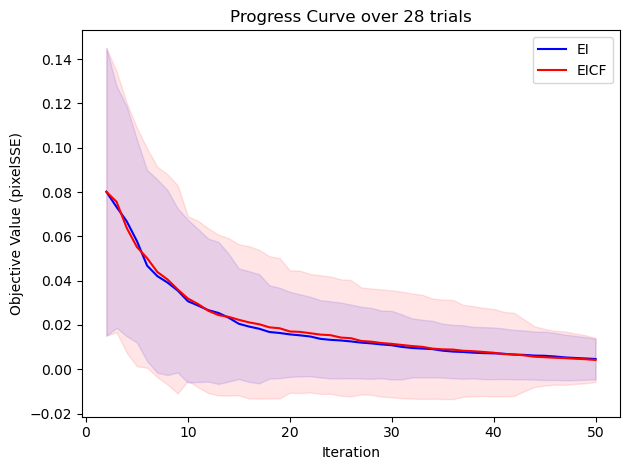

In [6]:
plt.plot(list(range(2,51)), mean_best_obj['EI'], label='EI', color='blue')
plt.fill_between(list(range(2,51)), lower_best_obj['EI'], upper_best_obj['EI'], color='blue', alpha=0.1)
plt.plot(list(range(2,51)), mean_best_obj['EICF'], label='EICF', color='red')
plt.fill_between(list(range(2,51)), lower_best_obj['EICF'], upper_best_obj['EICF'], color='red', alpha=0.1)
# plt.plot(list(range(2,51)), mean_best_obj['KG'], label='KG', color='green')
# plt.fill_between(list(range(2,51)), lower_best_obj['KG'], upper_best_obj['KG'], color='green', alpha=0.1)
# plt.plot(list(range(2,51)), mean_best_obj['TS'], label='TS', color='purple')
# plt.fill_between(list(range(2,51)), lower_best_obj['TS'], upper_best_obj['TS'], color='purple', alpha=0.1)
plt.xlabel('Iteration')
plt.ylabel('Objective Value (pixelSSE)')
plt.title(f'Progress Curve over {n_trial-1} trials')
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
mean_best_obj['EICF']

[0.08012114469527795,
 0.07560450819167784,
 0.06377963454505915,
 0.0551758938381028,
 0.050143707296772866,
 0.04393004310340722,
 0.04053073289602836,
 0.036045230011500076,
 0.031941830978377606,
 0.029439743076606576,
 0.026421013389605546,
 0.02446369860588291,
 0.02366501516621722,
 0.02232583746692618,
 0.021168784268294084,
 0.020323023223545122,
 0.018930012749710703,
 0.01851338387236145,
 0.017074191544359886,
 0.016879444014450455,
 0.016285787920223734,
 0.015650342291530745,
 0.015390224923397347,
 0.014324447764253342,
 0.01402387719389479,
 0.012784038678652203,
 0.012468129161315284,
 0.011848707097616712,
 0.011480028596280414,
 0.010970737865327538,
 0.010486603473156053,
 0.010119065334854401,
 0.009330710530248865,
 0.009008805357430011,
 0.008899854911202798,
 0.008362725387453212,
 0.008157995812340725,
 0.00783128313112152,
 0.007471613150159948,
 0.00687755869986918,
 0.006702028622459896,
 0.00628497101428502,
 0.0056737417159727814,
 0.005455262684571057,
 0

In [8]:
mean_best_obj['EI']

[0.08012115062207743,
 0.07326233207470027,
 0.06676767071608268,
 0.05783098030141097,
 0.0467772908692153,
 0.04206909820896915,
 0.03914590577878395,
 0.03555569278927887,
 0.03072957112628575,
 0.028763401705176436,
 0.02668879294364442,
 0.025427725875508265,
 0.02328661362765271,
 0.020535664932065368,
 0.019282591855738464,
 0.01828953899425764,
 0.016829803011056573,
 0.016385874006993716,
 0.015758048649141536,
 0.01532491914386724,
 0.014809196012078588,
 0.013741365394808577,
 0.013290295659046717,
 0.01301430078808941,
 0.012575169663273263,
 0.012036632676959586,
 0.011696640380353637,
 0.011214416484069104,
 0.010866548140184038,
 0.010094429234957267,
 0.009630371934656727,
 0.00936186655443907,
 0.009108372141694255,
 0.008399068097239512,
 0.00800495807338803,
 0.00781257314650078,
 0.007501116966461938,
 0.00729729474052399,
 0.00720473682457442,
 0.007004146418508634,
 0.006618818393345234,
 0.006500449602470835,
 0.006184941279969421,
 0.006093417098840715,
 0.00578